# 06. Risk Analysis

This notebook transforms the fraud predictions generated by the selected Random Forest model into actionable transaction risk insights.

The analysis focuses on:

- Fraud probability distribution
- Transaction risk segmentation
- Fraud rates across risk levels
- Transaction and monetary exposure by risk level
- High-risk transaction characteristics
- Risk patterns across transaction attributes
- Comparison of legitimate and fraudulent transaction behavior

The objective is to move from model performance to business-oriented risk intelligence by identifying which transactions require the greatest attention and where fraud exposure is concentrated.

## 1. Analysis Objective

The Random Forest model selected in Notebook 05 provides a fraud probability for each transaction.

Instead of treating every prediction as simply "fraud" or "not fraud", this notebook uses the predicted probability to create risk segments.

This allows transactions to be categorized into:

- **Low Risk** — low predicted probability of fraud
- **Medium Risk** — moderate predicted probability of fraud
- **High Risk** — elevated predicted probability of fraud
- **Critical Risk** — very high predicted probability of fraud

Risk segmentation provides a more practical framework for fraud monitoring because transactions with different levels of predicted risk can receive different levels of review or intervention.

In [1]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

# Display all columns when viewing DataFrames
pd.set_option("display.max_columns", None)

# Display floating-point values with four decimal places
pd.set_option("display.float_format", "{:.4f}".format)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load Model Predictions

The model predictions generated in Notebook 04 are loaded from the processed data directory.

The prediction dataset contains:

- Transaction index
- Actual fraud status
- Logistic Regression fraud probability
- Logistic Regression prediction
- Random Forest fraud probability
- Random Forest prediction

Since Random Forest was selected as the final model in Notebook 05, its predicted fraud probability will be used as the primary risk score.

In [2]:
# Load the predictions generated during the modelling stage
model_predictions = pd.read_parquet(
    "../data/processed/model_predictions.parquet"
)

# Display the shape of the prediction dataset
print("Prediction dataset shape:", model_predictions.shape)

# Display the first five rows
display(model_predictions.head())

Prediction dataset shape: (118108, 6)


,TransactionIndex,ActualFraud,LogisticRegression_Probability,LogisticRegression_Prediction,RandomForest_Probability,RandomForest_Prediction
0,472432,1,0.8571,1,0.7597,1
1,472433,0,0.0069,0,0.4892,0
2,472434,0,0.7200,1,0.6884,1
3,472435,0,0.7179,1,0.6975,1
4,472436,0,0.4080,0,0.4459,0


In [3]:
# Display the column names available in the prediction dataset
print("Available columns:")
print(model_predictions.columns.tolist())

Available columns:
['TransactionIndex', 'ActualFraud', 'LogisticRegression_Probability', 'LogisticRegression_Prediction', 'RandomForest_Probability', 'RandomForest_Prediction']


## 3. Prepare the Risk Analysis Dataset

For risk analysis, the Random Forest probability is treated as the primary risk score.

A higher probability indicates that the model considers the transaction more likely to be fraudulent.

The risk score will be used to divide transactions into four operational risk categories.

In [4]:
# Create a separate DataFrame so the original prediction data remains unchanged
risk_df = model_predictions.copy()

# Use the Random Forest fraud probability as the primary risk score
risk_df["Risk_Score"] = risk_df["RandomForest_Probability"]

# Verify the new risk score
display(
    risk_df[
        [
            "TransactionIndex",
            "ActualFraud",
            "Risk_Score"
        ]
    ].head()
)

,TransactionIndex,ActualFraud,Risk_Score
0,472432,1,0.7597
1,472433,0,0.4892
2,472434,0,0.6884
3,472435,0,0.6975
4,472436,0,0.4459


## 4. Risk Segmentation

Transactions are segmented using their predicted fraud probability.

The thresholds are defined as follows:

| Risk Level | Risk Score |
|---|---:|
| Low Risk | < 0.25 |
| Medium Risk | 0.25 – < 0.50 |
| High Risk | 0.50 – < 0.75 |
| Critical Risk | ≥ 0.75 |

These thresholds are used as an analytical framework rather than fixed business rules.

In a production fraud detection system, thresholds should be calibrated using historical fraud costs, investigation capacity, customer impact, and business risk tolerance.

In [5]:
# Define risk categories based on the Random Forest fraud probability
def assign_risk_level(score):
    """
    Convert a numerical fraud probability into an operational
    risk category.
    """

    # Very low predicted fraud probability
    if score < 0.25:
        return "Low Risk"

    # Moderate predicted fraud probability
    elif score < 0.50:
        return "Medium Risk"

    # High predicted fraud probability
    elif score < 0.75:
        return "High Risk"

    # Very high predicted fraud probability
    else:
        return "Critical Risk"


# Apply the risk classification to every transaction
risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(assign_risk_level)

# Check the resulting distribution
print("Risk segmentation completed.")

display(
    risk_df["Risk_Level"]
    .value_counts()
    .reindex(
        ["Low Risk", "Medium Risk", "High Risk", "Critical Risk"]
    )
    .rename("Transaction Count")
)

Risk segmentation completed.


Risk_Level
Low Risk         29715
Medium Risk      61557
High Risk        21657
Critical Risk     5179
Name: Transaction Count, dtype: int64

## 5. Risk Distribution

The first analysis examines how transactions are distributed across the four risk categories.

This helps determine whether the model assigns most transactions to low-risk categories while concentrating higher-risk scores among a smaller subset of transactions.

In [6]:
# Define the desired order of risk categories
risk_order = [
    "Low Risk",
    "Medium Risk",
    "High Risk",
    "Critical Risk"
]

# Count transactions within each risk category
risk_counts = (
    risk_df["Risk_Level"]
    .value_counts()
    .reindex(risk_order)
)

# Calculate the percentage of transactions in each risk category
risk_percentage = (
    risk_counts / len(risk_df) * 100
)

# Combine counts and percentages into a summary table
risk_distribution = pd.DataFrame({
    "Transaction Count": risk_counts,
    "Percentage": risk_percentage
})

display(risk_distribution)

,Transaction Count,Percentage
Risk_Level,,
Low Risk,29715,25.1592
Medium Risk,61557,52.1192
High Risk,21657,18.3366
Critical Risk,5179,4.3850


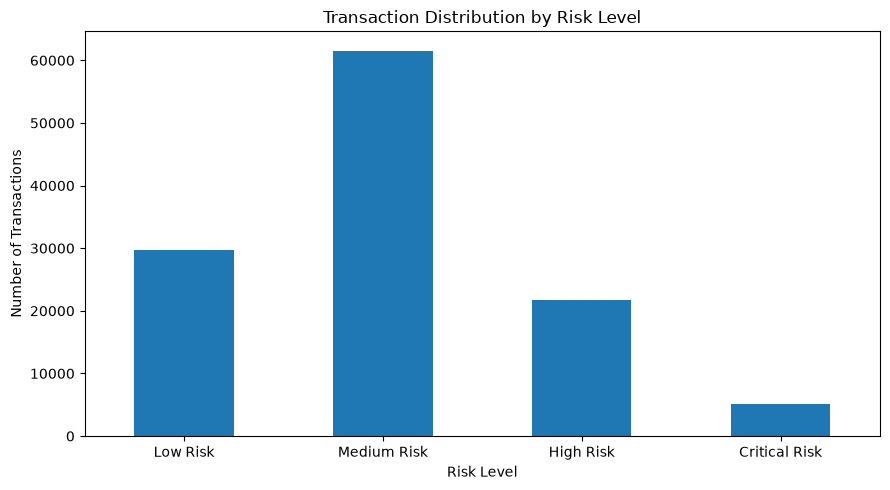

In [7]:
# Create a bar chart showing the number of transactions in each risk level
plt.figure(figsize=(9, 5))

risk_counts.plot(kind="bar")

plt.title("Transaction Distribution by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")

# Rotate category labels for readability
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Fraud Rate by Risk Level

Risk segmentation becomes useful when higher risk categories actually contain a higher proportion of fraudulent transactions.

The fraud rate for each risk level is calculated as:

**Fraud Rate = Fraudulent Transactions / Total Transactions × 100**

A strong risk segmentation should show an increasing fraud rate as the risk level increases.

In [8]:
# Calculate the total number of transactions in each risk category
risk_total = (
    risk_df
    .groupby("Risk_Level")
    .size()
    .reindex(risk_order)
)

# Calculate the number of fraudulent transactions in each risk category
risk_fraud = (
    risk_df
    .groupby("Risk_Level")["ActualFraud"]
    .sum()
    .reindex(risk_order)
)

# Calculate the fraud rate for each risk category
risk_fraud_rate = (
    risk_fraud / risk_total * 100
)

# Create a summary DataFrame
risk_fraud_summary = pd.DataFrame({
    "Total Transactions": risk_total,
    "Fraudulent Transactions": risk_fraud,
    "Fraud Rate (%)": risk_fraud_rate
})

display(risk_fraud_summary)

,Total Transactions,Fraudulent Transactions,Fraud Rate (%)
Risk_Level,,,
Low Risk,29715,183,0.6159
Medium Risk,61557,1246,2.0241
High Risk,21657,1337,6.1735
Critical Risk,5179,1298,25.0628


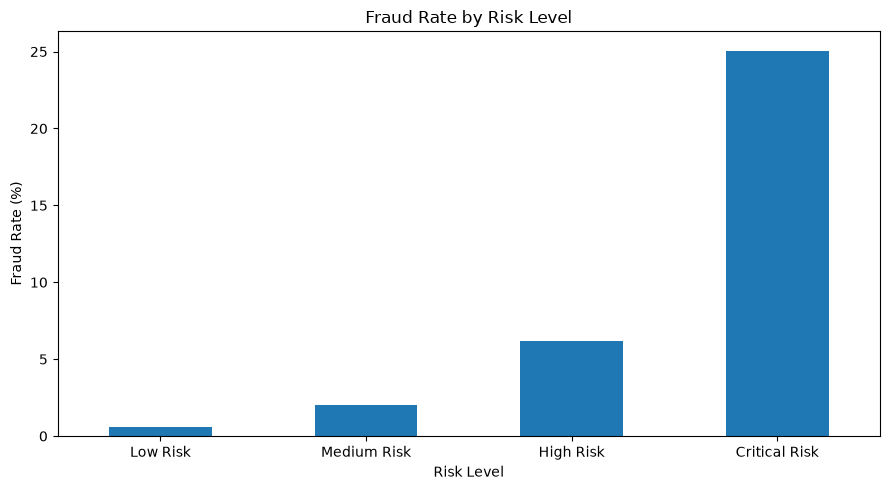

In [9]:
# Plot the fraud rate across risk categories
plt.figure(figsize=(9, 5))

risk_fraud_rate.plot(kind="bar")

plt.title("Fraud Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 7. Fraud Concentration

The previous analysis shows the fraud rate within each risk category.

This section examines how much of the total fraud is concentrated within the higher-risk segments.

This is important from an operational perspective because a fraud team may not be able to manually investigate every transaction.

If a relatively small percentage of transactions contains a large proportion of total fraud, those transactions can become the primary investigation queue.

In [10]:
# Calculate the total number of fraudulent transactions
total_fraud = risk_df["ActualFraud"].sum()

# Calculate fraud count by risk level
fraud_by_risk = (
    risk_df
    .groupby("Risk_Level")["ActualFraud"]
    .sum()
    .reindex(risk_order)
)

# Calculate the percentage of all fraud represented by each risk level
fraud_concentration = (
    fraud_by_risk / total_fraud * 100
)

# Create a summary table
fraud_concentration_df = pd.DataFrame({
    "Fraudulent Transactions": fraud_by_risk,
    "Share of Total Fraud (%)": fraud_concentration
})

display(fraud_concentration_df)

,Fraudulent Transactions,Share of Total Fraud (%)
Risk_Level,,
Low Risk,183,4.5030
Medium Risk,1246,30.6594
High Risk,1337,32.8986
Critical Risk,1298,31.9390


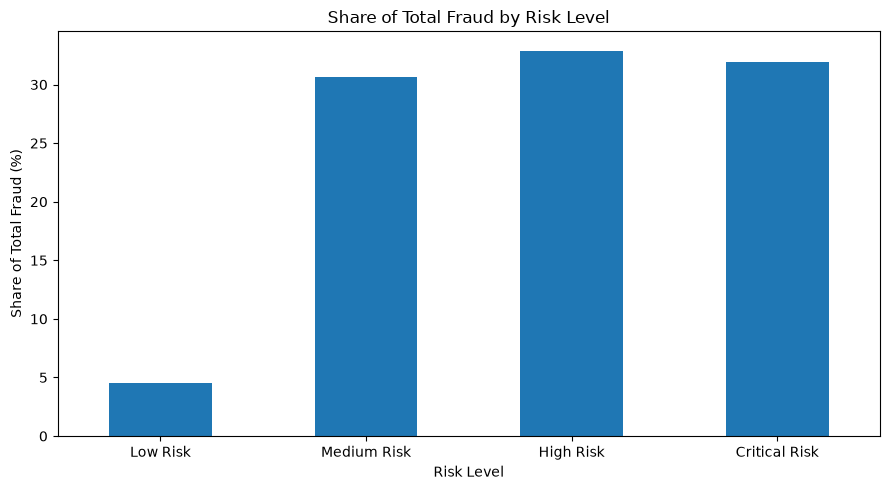

In [11]:
# Visualize the share of total fraud across risk categories
plt.figure(figsize=(9, 5))

fraud_concentration.plot(kind="bar")

plt.title("Share of Total Fraud by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Share of Total Fraud (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 8. Risk Score Distribution

The risk score represents the Random Forest model's estimated probability that a transaction is fraudulent.

Examining the distribution of these scores helps identify whether the model produces:

- Mostly low-risk predictions
- A broad range of risk scores
- A concentrated group of high-risk transactions
- Extremely high-risk transactions that may warrant immediate review

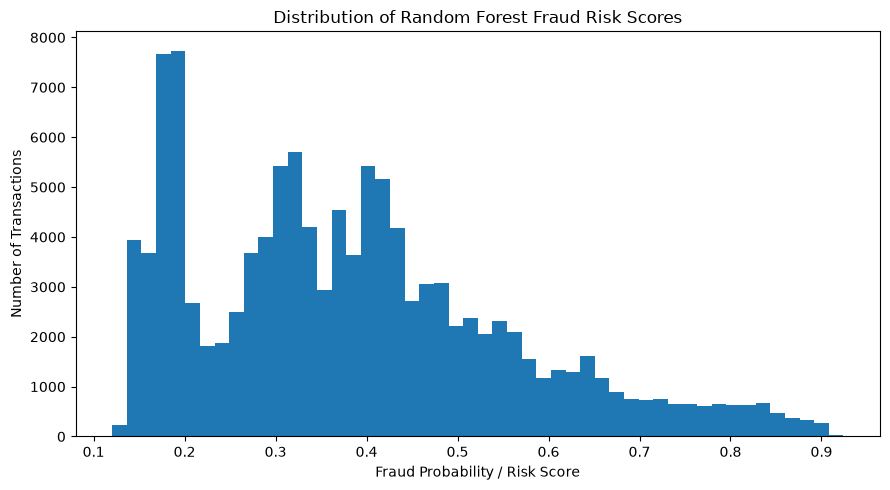

In [12]:
# Plot the distribution of Random Forest fraud probabilities
plt.figure(figsize=(9, 5))

plt.hist(
    risk_df["Risk_Score"],
    bins=50
)

plt.title("Distribution of Random Forest Fraud Risk Scores")
plt.xlabel("Fraud Probability / Risk Score")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

## 9. Compare Risk Scores for Legitimate and Fraudulent Transactions

A useful fraud detection model should generally assign higher risk scores to fraudulent transactions than to legitimate transactions.

This section compares the distribution of Random Forest risk scores across the two actual transaction classes.

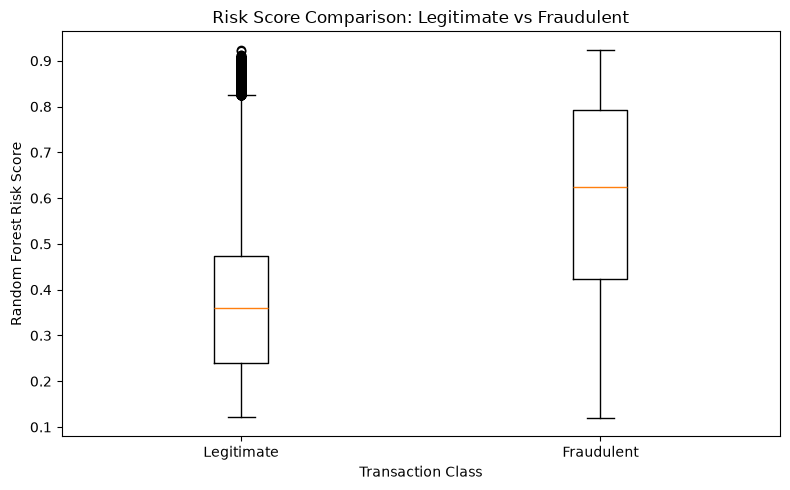

In [14]:
# Separate risk scores for legitimate and fraudulent transactions
legitimate_scores = risk_df.loc[
    risk_df["ActualFraud"] == 0,
    "Risk_Score"
]

fraud_scores = risk_df.loc[
    risk_df["ActualFraud"] == 1,
    "Risk_Score"
]

# Create a boxplot comparing the risk-score distributions
plt.figure(figsize=(8, 5))

plt.boxplot(
    [legitimate_scores, fraud_scores],
    tick_labels=["Legitimate", "Fraudulent"]
)

# Add chart title and axis labels
plt.title("Risk Score Comparison: Legitimate vs Fraudulent")
plt.xlabel("Transaction Class")
plt.ylabel("Random Forest Risk Score")

# Improve spacing around the chart
plt.tight_layout()

# Display the chart
plt.show()

## 10. Risk Score Statistics

To quantify the difference between legitimate and fraudulent transactions, summary statistics are calculated for both groups.

The analysis focuses on:

- Mean risk score
- Median risk score
- Minimum risk score
- Maximum risk score

In [15]:
# Calculate descriptive statistics for the Random Forest risk score
# separately for legitimate and fraudulent transactions.
risk_score_summary = (
    risk_df
    .groupby("ActualFraud")["Risk_Score"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max"
    ])
)

# Replace the numerical fraud labels with readable class names.
risk_score_summary.index = [
    "Legitimate",
    "Fraudulent"
]

# Display the summary statistics.
display(risk_score_summary)

,count,mean,median,min,max
Legitimate,114044,0.3769,0.3589,0.1211,0.9241
Fraudulent,4064,0.6029,0.6235,0.1204,0.9237


## 11. High-Risk Transaction Review

High-risk and critical-risk transactions represent the transactions with elevated predicted fraud probability.

These transactions are important from an operational perspective because they can be prioritized for additional verification or manual investigation.

This section measures:

- The number of High and Critical risk transactions
- The number of actual fraudulent transactions within these groups
- The fraud rate among elevated-risk transactions

A high fraud concentration within these categories would indicate that the risk segmentation can effectively prioritize investigation efforts.

In [16]:
# Select transactions classified as either High Risk or Critical Risk.
high_risk_transactions = risk_df[
    risk_df["Risk_Level"].isin(
        ["High Risk", "Critical Risk"]
    )
].copy()

# Count the total number of High/Critical risk transactions.
high_risk_count = len(high_risk_transactions)

# Count the number of actual fraudulent transactions
# within the High/Critical risk group.
high_risk_fraud_count = high_risk_transactions["ActualFraud"].sum()

# Calculate the fraud rate among High/Critical risk transactions.
high_risk_fraud_rate = (
    high_risk_fraud_count / high_risk_count * 100
    if high_risk_count > 0
    else 0
)

# Display the key results.
print("High/Critical-risk transactions:", f"{high_risk_count:,}")
print("Fraudulent transactions:", f"{high_risk_fraud_count:,}")
print(f"Fraud rate: {high_risk_fraud_rate:.2f}%")

High/Critical-risk transactions: 26,836
Fraudulent transactions: 2,635
Fraud rate: 9.82%


## 12. Risk Level Performance Summary

The risk segmentation is evaluated by comparing the observed fraud rate across risk levels.

A useful risk segmentation should demonstrate a clear relationship between predicted risk and actual fraud:

- Lower-risk groups should generally contain fewer fraudulent transactions.
- Higher-risk groups should generally contain higher fraud rates.
- High and Critical risk groups should capture a meaningful proportion of the total fraud.

This provides evidence of whether the model's probability scores can be converted into useful operational risk categories.

In [17]:
# Create a comprehensive summary of each risk category.
risk_performance = pd.DataFrame({
    "Total Transactions": risk_total,
    "Fraudulent Transactions": risk_fraud,
    "Fraud Rate (%)": risk_fraud_rate,
    "Share of Total Fraud (%)": fraud_concentration
})

# Display the risk performance table.
display(risk_performance)

,Total Transactions,Fraudulent Transactions,Fraud Rate (%),Share of Total Fraud (%)
Risk_Level,,,,
Low Risk,29715,183,0.6159,4.5030
Medium Risk,61557,1246,2.0241,30.6594
High Risk,21657,1337,6.1735,32.8986
Critical Risk,5179,1298,25.0628,31.9390


## 13. Fraud Capture in Elevated-Risk Transactions

Fraud investigation teams typically have limited capacity.

Therefore, an important business question is:

> What percentage of all fraudulent transactions can be captured by focusing investigation efforts on High and Critical risk transactions?

This analysis measures the concentration of actual fraud within the elevated-risk segments.

In [19]:
# Calculate the total number of fraudulent transactions in the dataset.
total_fraud = risk_df["ActualFraud"].sum()

# Calculate the number of fraudulent transactions
# classified as High Risk or Critical Risk.
elevated_risk_fraud = risk_df.loc[
    risk_df["Risk_Level"].isin(
        ["High Risk", "Critical Risk"]
    ),
    "ActualFraud"
].sum()

# Calculate the percentage of total fraud captured
# by the High/Critical risk segments.
elevated_risk_fraud_share = (
    elevated_risk_fraud / total_fraud * 100
    if total_fraud > 0
    else 0
)

print(
    f"Fraud captured in High/Critical risk levels: "
    f"{elevated_risk_fraud_share:.2f}%"
)

Fraud captured in High/Critical risk levels: 64.84%


## 14. Risk Score Distribution

The Random Forest risk score represents the estimated probability that a transaction is fraudulent.

Examining the distribution of these scores helps identify how confidently the model separates transactions into different levels of risk.

A useful model should generally assign higher risk scores to fraudulent transactions than to legitimate transactions.

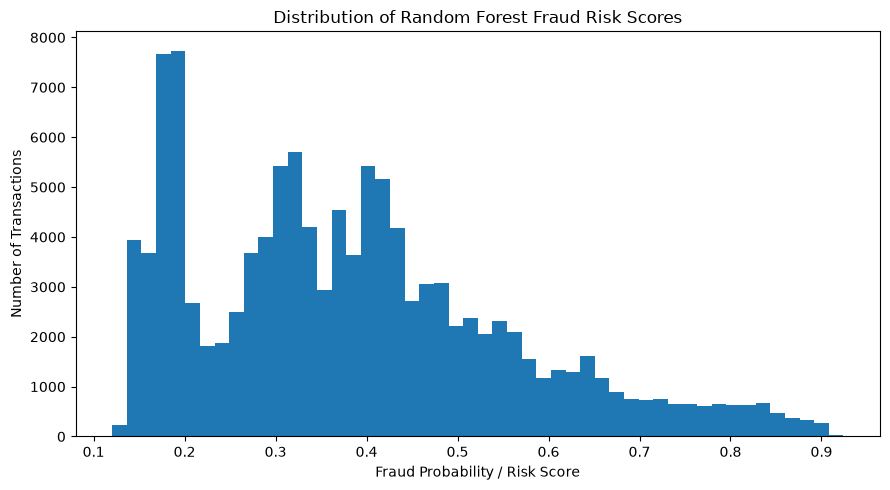

In [20]:
# Plot the distribution of Random Forest risk scores.
plt.figure(figsize=(9, 5))

plt.hist(
    risk_df["Risk_Score"],
    bins=50
)

# Add descriptive chart labels.
plt.title("Distribution of Random Forest Fraud Risk Scores")
plt.xlabel("Fraud Probability / Risk Score")
plt.ylabel("Number of Transactions")

# Improve chart spacing.
plt.tight_layout()

# Display the chart.
plt.show()

## 15. Risk Score Comparison by Actual Class

This section compares the Random Forest risk scores assigned to legitimate and fraudulent transactions.

The purpose is to determine whether fraudulent transactions generally receive higher risk scores than legitimate transactions.

A clear separation between the two groups would indicate that the model's probability estimates are useful for ranking transactions according to fraud risk.

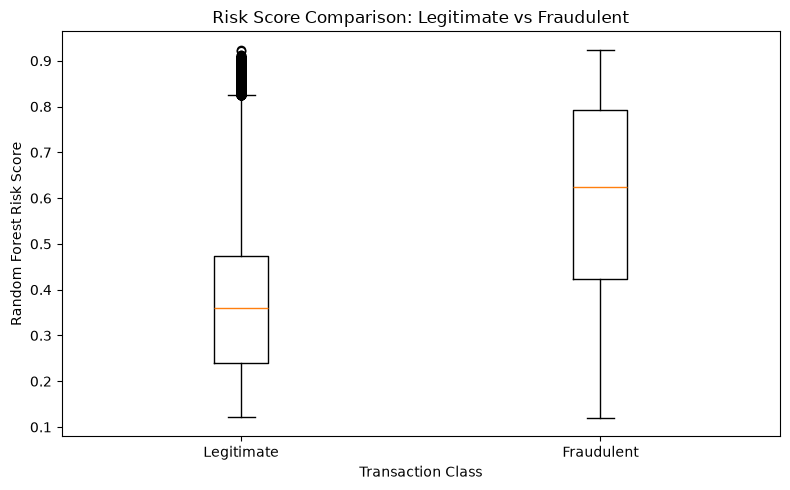

In [21]:
# Extract risk scores for legitimate transactions.
legitimate_scores = risk_df.loc[
    risk_df["ActualFraud"] == 0,
    "Risk_Score"
]

# Extract risk scores for fraudulent transactions.
fraud_scores = risk_df.loc[
    risk_df["ActualFraud"] == 1,
    "Risk_Score"
]

# Create a boxplot comparing the two distributions.
plt.figure(figsize=(8, 5))

plt.boxplot(
    [legitimate_scores, fraud_scores],
    tick_labels=["Legitimate", "Fraudulent"]
)

# Add descriptive chart labels.
plt.title("Risk Score Comparison: Legitimate vs Fraudulent")
plt.xlabel("Transaction Class")
plt.ylabel("Random Forest Risk Score")

# Improve spacing around the chart.
plt.tight_layout()

# Display the chart.
plt.show()

## 16. Risk Score Statistics by Transaction Class

To quantify the difference between legitimate and fraudulent transactions, descriptive statistics are calculated for their Random Forest risk scores.

The analysis includes:

- Number of transactions
- Mean risk score
- Median risk score
- Minimum risk score
- Maximum risk score

Higher average and median scores for fraudulent transactions would indicate that the model assigns greater predicted risk to actual fraud cases.

In [22]:
# Calculate descriptive statistics for the risk score
# grouped by the actual transaction class.
risk_score_summary = (
    risk_df
    .groupby("ActualFraud")["Risk_Score"]
    .agg(
        Transaction_Count="count",
        Mean_Risk_Score="mean",
        Median_Risk_Score="median",
        Minimum_Risk_Score="min",
        Maximum_Risk_Score="max"
    )
)

# Replace numerical class labels with readable names.
risk_score_summary.index = [
    "Legitimate",
    "Fraudulent"
]

# Display the statistics.
display(risk_score_summary)

,Transaction_Count,Mean_Risk_Score,Median_Risk_Score,Minimum_Risk_Score,Maximum_Risk_Score
Legitimate,114044,0.3769,0.3589,0.1211,0.9241
Fraudulent,4064,0.6029,0.6235,0.1204,0.9237


## 17. Overall Risk Analysis Summary

The risk analysis converts the Random Forest fraud probabilities into operational risk categories and evaluates how effectively these categories concentrate actual fraud.

The analysis considers:

- Overall fraud rate
- Distribution of transactions across risk levels
- Fraud rate by risk level
- Share of total fraud within each risk level
- Fraud captured by High and Critical risk categories
- Separation between legitimate and fraudulent risk scores

These results provide the foundation for translating model predictions into practical fraud-monitoring strategies.

In [23]:
# Calculate the overall fraud rate in the evaluation dataset.
overall_fraud_rate = (
    risk_df["ActualFraud"].mean() * 100
)

# Identify the risk category with the highest observed fraud rate.
highest_risk_category = risk_fraud_rate.idxmax()

# Retrieve the fraud rate for that category.
highest_risk_category_rate = risk_fraud_rate.max()

# Calculate the percentage of transactions classified
# as High Risk or Critical Risk.
elevated_risk_transaction_share = (
    high_risk_count / len(risk_df) * 100
)

# Print the main risk analysis findings.
print("=" * 50)
print("RISK ANALYSIS SUMMARY")
print("=" * 50)

print(
    f"Overall fraud rate: "
    f"{overall_fraud_rate:.2f}%"
)

print(
    f"High/Critical risk transactions: "
    f"{high_risk_count:,}"
)

print(
    f"High/Critical risk transaction share: "
    f"{elevated_risk_transaction_share:.2f}%"
)

print(
    f"Fraud captured in High/Critical risk levels: "
    f"{elevated_risk_fraud_share:.2f}%"
)

print(
    f"Highest fraud-rate category: "
    f"{highest_risk_category}"
)

print(
    f"Highest category fraud rate: "
    f"{highest_risk_category_rate:.2f}%"
)

RISK ANALYSIS SUMMARY
Overall fraud rate: 3.44%
High/Critical risk transactions: 26,836
High/Critical risk transaction share: 22.72%
Fraud captured in High/Critical risk levels: 64.84%
Highest fraud-rate category: Critical Risk
Highest category fraud rate: 25.06%


## Final Risk Analysis Summary

The Random Forest fraud probabilities were transformed into four operational risk categories: Low Risk, Medium Risk, High Risk, and Critical Risk.

The analysis evaluates fraud concentration, fraud rates, risk-score distributions, and the number of transactions requiring elevated attention.

The risk segmentation provides a practical framework for prioritizing fraud investigations. Rather than treating every transaction equally, higher-risk transactions can be prioritized for additional verification or manual review.

### Key Business Interpretation

- **Low Risk:** Transactions with relatively low predicted fraud probability and suitable for normal processing.
- **Medium Risk:** Transactions that may benefit from additional monitoring or automated verification.
- **High Risk:** Transactions that should receive enhanced verification or investigation priority.
- **Critical Risk:** Transactions with the highest predicted fraud probability and the strongest candidates for immediate review.

The effectiveness of the segmentation should be judged by whether fraud rates increase across risk levels and whether High/Critical risk categories capture a meaningful share of total fraud.

The thresholds used in this notebook are analytical thresholds rather than fixed production rules. In a real fraud detection system, thresholds should be calibrated using investigation capacity, financial loss, false-positive costs, customer impact, and overall business risk tolerance.

The findings from this analysis will be carried forward into the final **Fraud Risk Insights** stage, where the analytical results will be translated into actionable business recommendations.